# Exploring Mayan Dataset

In [1]:
!nvidia-smi

Thu May 21 02:05:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
# =========================================================
# 1) INSTALACIÓN
# =========================================================

# Quitar torchcodec — no lo necesitas para procesar .wav con soundfile
!pip uninstall -y torchvision torchcodec nibabel -q

# torchaudio actualizado (Colab ya trae torch alineado con su CUDA)
!pip install -q -U torchaudio

!pip install pyctcdecode

# Paquetes del pipeline
# - datasets 3.6.0: última versión estable que decodifica audio con soundfile
#   (las versiones 4.x dependen de torchcodec, que requiere FFmpeg 6+)
# - soundfile: decodifica .wav directamente como numpy arrays
!pip install -q -U \
    "datasets[audio]==3.6.0" \
    "huggingface_hub" \
    "soundfile" \
    "librosa" \
    "evaluate" \
    "jiwer" \
    "accelerate" \
    "transformers @ git+https://github.com/huggingface/transformers.git"

# Verificación rápida
import soundfile as sf
import datasets
print(f"datasets:  {datasets.__version__}")
print(f"soundfile: {sf.__version__}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.26 requires torchvision, which is not installed.
datasets:  3.6.0
soundfile: 0.13.1


In [2]:
from datasets import load_dataset, Audio
import os
import numpy as np
import pandas as pd

In [3]:
DATASET_REPO = "mau-cr/mayan-voice"

In [4]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
ds = load_dataset(DATASET_REPO)
ds_train = ds["train"]
ds_train

Dataset({
    features: ['utt_id', 'maya', 'spk_id', 'audio'],
    num_rows: 2535
})

In [ ]:
from collections import Counter

for split in ds.keys():
    rates = Counter(ds[split][i]["audio"]["sampling_rate"] for i in range(len(ds[split])))
    print(f"{split}: {dict(rates)}")

train: {16000: 2535}


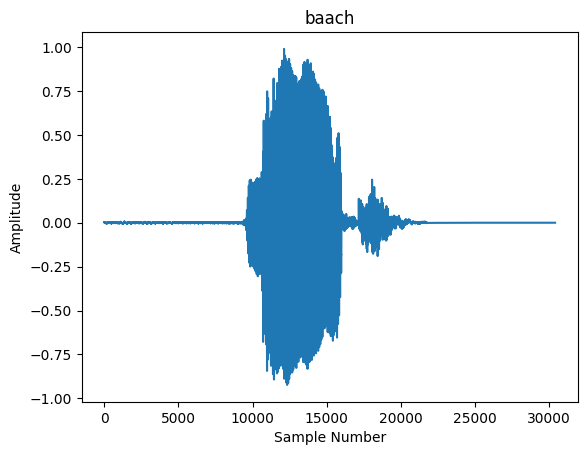

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Audio, display

sample = ds_train[0]

transcription = sample["maya"]
audio = sample["audio"]["array"]

plt.plot(audio)
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.title(transcription)
plt.show()
Audio(ds["train"][0]["audio"]["array"], rate=16000)

In [7]:
from datasets import ClassLabel
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    print(len(dataset))
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])
    display(HTML(df.to_html()))


In [8]:
show_random_elements(ds_train.remove_columns(["audio", "utt_id", "spk_id"]), num_examples=10)


2535


,maya
0,bix a beel xunáan
1,uti'al u beeto'ob u t'aanil tuláakal uti'al u k'u'ubul mare chan ya'ab ba'al ku bisa'al ya'ab ma creertik wa chéen ch'a'bil
2,le lugar tu'ux yaano'ono táan bin u je'ikubáaj le lu'umo je'elo tene ka jo'op in sajaktal ka tin mach u k'ab in watan kin wa'alik ti'e ma in wojel ba'ax ku yúuchuli
3,le máako'ob kíinso'obo ti bin yaano'obi le ka jtúuxta'ab orden tak kaampeche ka u'uluk ilbil bin le ba'ax ts'u yúuchulo ti máan áak'ab ti'ob carcele
4,t kanaj ts'íib
5,wilik tu sen jaanta'al tumen ba'alche'o ka ts'aik u yuk'ule ku chan ch'éemel ujum teche káan a k'ubil le koolo je kin k'ubika tumen in koola kanante'ex teen in kool ma jach cha'ike'ex u jaanta'al tuláakal bueno te ich kool beyo máax
6,tia'an te xka'anal kool xka'anal koole ti kaja'ani tu'ux le xka'anal koolo jump'éel kaaj ka'anal koolo jump'éel rancho tu formart le máako jump'éel rancho tu formart le máako chéen k'áax chéen k'áax ku ya'aliko'ob le formart le rancho le máako
7,te beel ts'íibal ch'e'en yaan in kool te naats'a míin cuatro kilometros weye te jáal carreterao tia'ani yaan teen xan uláak jump'éel tanda te banda tu'ux yaan in wakaxo buka'aj ka kolik túun beyo
8,ja'ak' k óole'ex
9,ya'ax


## Recover tokenizer if saved on the Hub

In [6]:
target_lang = "yua"
user = "mau-cr"
repo_name = "wav2vec2-large-mms-1b-mayan-colab"

In [7]:
from transformers import Wav2Vec2CTCTokenizer
import re

save_local = False

try:
  tokenizer = Wav2Vec2CTCTokenizer.from_pretrained(
      f"{user}/{repo_name}",
      target_lang=target_lang
  )
except:
  """
  If tokenizer is not saved on the hub,
  we can build the vocabulary from the training data
  and save it locally. Also we can create the tokenizer and push it
  to the hub (what is the tutorial recommend)

  tutorial: https://huggingface.co/blog/mms_adapters#fine-tuning-mms-adapter-models-for-multi-lingual-asr
  """
  chars_to_remove_regex = '[\,\?\¿\$\.\!\-\;\:\"\“\%\‘\”\�]'

  def remove_special_characters(batch):
      batch["maya"] = re.sub(chars_to_remove_regex, '', batch["maya"]).lower()
      return batch

  ds_train_clean = ds_train.map(remove_special_characters)

  show_random_elements(ds_train_clean.remove_columns(["audio", "utt_id", "spk_id"]), num_examples=10)

  def extract_all_chars(batch):
    all_text = " ".join(batch["maya"])
    vocab = list(set(all_text))
    return {"vocab": [vocab], "all_text": [all_text]}

  vocab_train = ds_train_clean.map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=ds_train_clean.column_names)

  vocab_list = list(set(vocab_train["vocab"][0]))

  vocab_dict = {v: k for k, v in enumerate(sorted(vocab_list))}

  vocab_dict["|"] = vocab_dict[" "]
  del vocab_dict[" "]

  vocab_dict["[UNK]"] = len(vocab_dict)
  vocab_dict["[PAD]"] = len(vocab_dict)
  len(vocab_dict)

  new_vocab_dict = {target_lang: vocab_dict}

  save_local = True


<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:20: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_57472/637155130.py:20: SyntaxWarning: invalid escape sequence '\,'
  chars_to_remove_regex = '[\,\?\¿\$\.\!\-\;\:\"\“\%\‘\”\�]'


In [11]:
from transformers import Wav2Vec2CTCTokenizer
from google.colab import drive
from pathlib import Path
import json

if save_local:
  drive.mount('/content/drive')
  base_folder = "/content/drive/MyDrive/thesis-mayan-ai/"
  vocab_json = Path(base_folder) / "vocab" / "vocab.json"
  vocab_json.parent.mkdir(exist_ok=True)
  with open(vocab_json, 'w') as vocab_file:
      json.dump(new_vocab_dict, vocab_file)

  tokenizer = Wav2Vec2CTCTokenizer.from_pretrained(
      vocab_json.parent,
      unk_token="[UNK]",
      pad_token="[PAD]",
      word_delimiter_token="|",
      target_lang=target_lang
  )
  tokenizer.push_to_hub(repo_name)

In [12]:
from transformers import Wav2Vec2FeatureExtractor

feature_extractor = Wav2Vec2FeatureExtractor(
  feature_size=1,
  sampling_rate=16000,
  padding_value=0.0,
  do_normalize=True,
  return_attention_mask=True
)

In [13]:
from transformers import Wav2Vec2Processor, Wav2Vec2ProcessorWithLM

processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)


## Training the model

In [14]:
from huggingface_hub import HfApi

In [15]:
TEST_SPEAKERS = {"spk_002", "spk_020", "spk_024", "spk_028"}
VAL_SPEAKERS  = {"spk_009", "spk_029"}

def asignar_split(ejemplo):
    spk = ejemplo["spk_id"]
    if spk in TEST_SPEAKERS:
        return "test"
    elif spk in VAL_SPEAKERS:
        return "validation"
    else:
        return "train"

# Filtrar cada split
test_ds  = ds_train.filter(lambda x: x["spk_id"] in TEST_SPEAKERS)
val_ds   = ds_train.filter(lambda x: x["spk_id"] in VAL_SPEAKERS)
train_ds = ds_train.filter(lambda x: x["spk_id"] not in TEST_SPEAKERS | VAL_SPEAKERS)

# Verificar duraciones reales
def duracion_total(dataset, sr=16000):
  total = sum(len(ex["audio"]["array"]) / sr for ex in dataset)
  return total / 60  # en minutos

print(f"Train: {duracion_total(train_ds):.1f} min, {len(train_ds)} ejemplos")
print(f"Val:   {duracion_total(val_ds):.1f} min, {len(val_ds)} ejemplos")
print(f"Test:  {duracion_total(test_ds):.1f} min, {len(test_ds)} ejemplos")

Filter:   0%|          | 0/2535 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2535 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2535 [00:00<?, ? examples/s]

Train: 222.9 min, 2116 ejemplos
Val:   14.8 min, 152 ejemplos
Test:  24.2 min, 267 ejemplos


In [16]:
def crear_subsets_incrementales(dataset, minutos_lista, seed=42, sr=16000):
    """
    Devuelve un dict {minutos: subset} con subsets anidados.
    El subset de N minutos contiene todo lo del subset de N-20 minutos.
    """
    # Un solo shuffle al inicio: el orden queda fijo
    ds_shuffled = dataset.shuffle(seed=seed)

    # Precalcular duración de cada ejemplo (más rápido que iterarlo)
    duraciones = [len(ex["audio"]["array"]) / sr for ex in ds_shuffled]

    subsets = {}
    for min_objetivo in sorted(minutos_lista):
        seg_objetivo = min_objetivo * 60
        acumulado = 0.0
        corte = 0
        for i, dur in enumerate(duraciones):
            if acumulado + dur > seg_objetivo:
                break
            acumulado += dur
            corte = i + 1

        subsets[min_objetivo] = ds_shuffled.select(range(corte))
        print(f"{min_objetivo:3d} min objetivo → {corte} ejemplos, "
              f"{acumulado/60:.2f} min reales")

    return subsets

In [17]:
# Uso
minutos = list(range(20, 241, 20))  # [20, 40, 60, ..., 240]
subsets = crear_subsets_incrementales(train_ds, minutos)

 20 min objetivo → 174 ejemplos, 19.94 min reales
 40 min objetivo → 354 ejemplos, 39.87 min reales
 60 min objetivo → 542 ejemplos, 59.94 min reales
 80 min objetivo → 735 ejemplos, 79.98 min reales
100 min objetivo → 940 ejemplos, 99.93 min reales
120 min objetivo → 1128 ejemplos, 119.87 min reales
140 min objetivo → 1324 ejemplos, 139.85 min reales
160 min objetivo → 1521 ejemplos, 159.87 min reales
180 min objetivo → 1708 ejemplos, 179.92 min reales
200 min objetivo → 1900 ejemplos, 199.91 min reales
220 min objetivo → 2085 ejemplos, 219.91 min reales
240 min objetivo → 2116 ejemplos, 222.89 min reales


In [18]:
from dataclasses import dataclass
from typing import Dict, List, Union
import os, gc, json, csv, torch

@dataclass
class DataCollatorCTCWithPadding:
  processor: Wav2Vec2Processor
  padding: Union[bool, str] = True

  def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]):
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids":   f["labels"]}        for f in features]

        batch = self.processor.pad(input_features, padding=self.padding, return_tensors="pt")
        labels_batch = self.processor.pad(labels=label_features, padding=self.padding, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch["labels"] = labels
        return batch

In [19]:
data_collator = DataCollatorCTCWithPadding(
    processor=processor,
    padding=True
)

In [20]:
import evaluate
wer_metric = evaluate.load("wer")

In [21]:
def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str  = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

# --- Preprocesamiento de cada ejemplo (audio -> input_values, texto -> labels) ---
def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_values"] = processor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_values[0]
    batch["labels"] = processor(text=batch["maya"]).input_ids  # ajusta "sentence" al nombre de tu columna
    return batch

In [22]:
val_ds_prep  = val_ds.map(prepare_dataset, remove_columns=val_ds.column_names)
test_ds_prep = test_ds.map(prepare_dataset, remove_columns=test_ds.column_names)

Map:   0%|          | 0/152 [00:00<?, ? examples/s]

Map:   0%|          | 0/267 [00:00<?, ? examples/s]

In [23]:
results_repo = f"{user}/mms-maya-curve-results"

In [24]:
api = HfApi()
api.create_repo(repo_id=results_repo, exist_ok=True, repo_type="model")

RepoUrl('https://huggingface.co/mau-cr/mms-maya-curve-results', endpoint='https://huggingface.co', repo_type='model', repo_id='mau-cr/mms-maya-curve-results')

In [25]:
import json
from transformers import (
    Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor, Wav2Vec2ForCTC,
    TrainingArguments, Trainer,
)
import shutil

def entrenar_y_evaluar(train_subset, min_obj, min_reales):
    run_name   = f"mms-maya-{min_obj:03d}min"
    output_dir = f"/content/runs/{run_name}"
    repo_id    = f"{user}/{run_name}"

    # Preprocesar el subset
    train_prep = train_subset.map(prepare_dataset, remove_columns=train_subset.column_names)

    # --- Modelo fresco en cada corrida ---
    model = Wav2Vec2ForCTC.from_pretrained(
        "facebook/mms-1b-all",
        attention_dropout=0.0, hidden_dropout=0.0, feat_proj_dropout=0.0,
        layerdrop=0.0, ctc_loss_reduction="mean",
        pad_token_id=processor.tokenizer.pad_token_id,
        vocab_size=len(processor.tokenizer),
        ignore_mismatched_sizes=True,
        target_lang=target_lang,
    )
    model.init_adapter_layers()
    model.freeze_base_model()
    for name, param in model._get_adapters().items():
        param.requires_grad = True

    # --- Training args ---
    training_args = TrainingArguments(
      output_dir=output_dir,
      #group_by_length=True,
      per_device_train_batch_size=32,
      eval_strategy="steps",
      num_train_epochs=40,
      gradient_checkpointing=True,
      fp16=True,
      save_steps=100,
      eval_steps=100,
      logging_steps=100,
      learning_rate=1e-3,
      warmup_steps=100,
      save_total_limit=2,
      push_to_hub=True,
    )

    trainer = Trainer(
        model=model,
        data_collator=data_collator,
        args=training_args,
        compute_metrics=compute_metrics,
        train_dataset=train_prep,
        eval_dataset=val_ds_prep,
        processing_class=processor.feature_extractor,
    )

    trainer.train()                                  # entrena
    test_results = trainer.evaluate(                 # evalúa en test (1 sola vez)
        eval_dataset=test_ds_prep, metric_key_prefix="test"
    )
    wer_test = test_results["test_wer"]

    trainer.push_to_hub(commit_message=f"End of training ({min_obj} min subset)")

    log_path = f"{output_dir}/log_history.json"
    with open(log_path, "w") as f:
        json.dump(trainer.state.log_history, f, indent=2)

    api.upload_file(
        path_or_fileobj=log_path,
        path_in_repo="log_history.json",
        repo_id=repo_id,
        repo_type="model",
        commit_message="Add training log history",
    )

    # --- Model card con el WER de test ---
    model_card = f"""---
language: yua
tags:
- automatic-speech-recognition
- mms
- maya-yucatec
- low-resource
license: cc-by-nc-4.0
---

# MMS-1b-all fine-tuned on Maya Yucatec ({min_obj} min subset)

Punto del experimento de curva WER vs minutos de entrenamiento (réplica de Bartley 2025).

## Resultados

| Métrica          | Valor          |
|------------------|----------------|
| Minutos objetivo | {min_obj}      |
| Minutos reales   | {min_reales:.2f} |
| WER (test)       | {wer_test:.4f} |

## Detalles del entrenamiento

- Modelo base: `facebook/mms-1b-all`
- Target language adapter: `{target_lang}`
- Test set: 4 hablantes hold-out (24.1 min) — spk 002, 020, 024, 028
- Validation set: 2 hablantes hold-out (14.7 min) — spk 009, 029
- max_steps: 2000
- learning_rate: 1e-3
- batch_size efectivo: 16 (8 × 2 grad accum)
"""
    api.upload_file(
        path_or_fileobj=model_card.encode("utf-8"),
        path_in_repo="README.md",
        repo_id=repo_id,
        repo_type="model",
        commit_message=f"Add model card with test WER ({wer_test:.4f})",
    )

    # --- Cleanup local ---
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()
    shutil.rmtree(output_dir, ignore_errors=True)

    return wer_test

In [26]:
def subsets_ya_corridos():
    """Lee el CSV del Hub si existe y devuelve los minutos objetivo ya procesados."""
    try:
        from huggingface_hub import hf_hub_download
        path = hf_hub_download(
            repo_id=results_repo, filename="resultados_curva.csv", repo_type="model"
        )
        ya_corridos = set()
        with open(path) as f:
            reader = csv.reader(f)
            next(reader, None)
            for row in reader:
                if row:
                    ya_corridos.add(int(row[0]))
        return ya_corridos, path
    except Exception:
        return set(), None

### Run de prueba

### Loop de todos los subsets

Correr todos los subsets

In [ ]:
# Recuperar progreso previo (si lo hay)
ya_corridos, csv_remoto = subsets_ya_corridos()
csv_path = "/content/resultados_curva.csv"

if csv_remoto:
    shutil.copy(csv_remoto, csv_path)
    print(f"✓ Reanudando desde el Hub. Ya completados: {sorted(ya_corridos)}")
else:
    with open(csv_path, "w", newline="") as f:
        csv.writer(f).writerow(["minutos_objetivo", "minutos_reales", "wer_test"])
    print("✓ Empezando experimento desde cero.")

# Loop principal
for min_obj in sorted(subsets.keys()):
    if min_obj in ya_corridos:
        print(f"\n⏭  Saltando {min_obj} min (ya completado)")
        continue

    subset = subsets[min_obj]
    min_reales = sum(len(ex["audio"]["array"]) / 16000 for ex in subset) / 60

    print(f"\n{'='*60}")
    print(f"▶ Entrenando con {min_obj} min objetivo ({min_reales:.2f} min reales)")
    print('='*60)

    wer = entrenar_y_evaluar(subset, min_obj, min_reales)

    # Append al CSV local
    with open(csv_path, "a", newline="") as f:
        csv.writer(f).writerow([min_obj, f"{min_reales:.2f}", f"{wer:.4f}"])

    # Sincronizar al Hub inmediatamente
    api.upload_file(
        path_or_fileobj=csv_path,
        path_in_repo="resultados_curva.csv",
        repo_id=results_repo,
        repo_type="model",
        commit_message=f"Add result for {min_obj} min subset (WER={wer:.4f})",
    )

    print(f"\n✓ {min_obj} min → WER test = {wer:.4f} [subido al Hub]")

print("\n🎉 Experimento completo.")

resultados_curva.csv:   0%|          | 0.00/261 [00:00<?, ?B/s]

✓ Reanudando desde el Hub. Ya completados: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]

⏭  Saltando 20 min (ya completado)

⏭  Saltando 40 min (ya completado)

⏭  Saltando 60 min (ya completado)

⏭  Saltando 80 min (ya completado)

⏭  Saltando 100 min (ya completado)

⏭  Saltando 120 min (ya completado)

⏭  Saltando 140 min (ya completado)

⏭  Saltando 160 min (ya completado)

⏭  Saltando 180 min (ya completado)

⏭  Saltando 200 min (ya completado)

⏭  Saltando 220 min (ya completado)

⏭  Saltando 240 min (ya completado)

🎉 Experimento completo.


In [ ]:
from huggingface_hub import hf_hub_download
import json
import pandas as pd
import matplotlib.pyplot as plt

minutos_objetivo = range(20, 260, 20)  # ajusta a los tuyos

filas = []
historias = {}

for m in minutos_objetivo:
    repo_id = f"{user}/mms-maya-{m:03d}min"
    log_path = hf_hub_download(repo_id=repo_id, filename="log_history.json")

    with open(log_path) as f:
        log = json.load(f)

    historias[m] = log

    # Buscar la entrada de test (la última con 'test_wer')
    test_entries = [r for r in log if "test_wer" in r]
    if not test_entries:
        print(f"  ⚠️  {m} min: no se encontró test_wer en log_history")
        continue

    wer_test = test_entries[-1]["test_wer"]
    filas.append({"min_obj": m, "wer_test": wer_test})

df = pd.DataFrame(filas).sort_values("min_obj")
print(df)

log_history.json: 0.00B [00:00, ?B/s]

    min_obj  wer_test
0        20  0.533764
1        40  0.493700
2        60  0.481422
3        80  0.465913
4       100  0.451373
5       120  0.428110
6       140  0.422294
7       160  0.432310
8       180  0.404847
9       200  0.405170
10      220  0.398061
11      240  0.403554


<Axes: xlabel='Minutos de entrenamiento', ylabel='WER'>

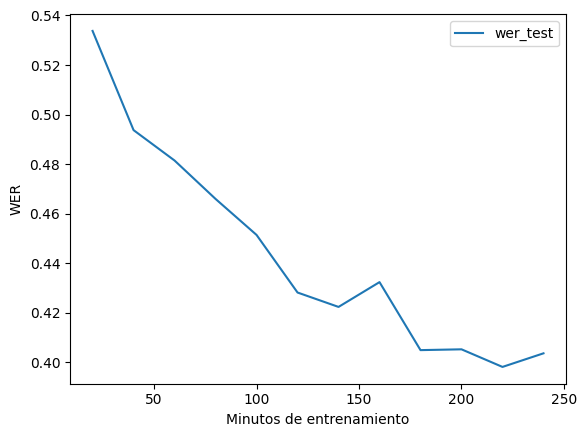

In [ ]:
df.plot(x="min_obj", y="wer_test", xlabel="Minutos de entrenamiento", ylabel="WER")

## Character Error Rate

In [ ]:
from huggingface_hub import HfApi
from tqdm import tqdm

api = HfApi()
user = "mau-cr"
minutos_objetivo = range(20, 260, 20)

# Aseguramos que el processor tenga el target_lang configurado antes de subir
processor.tokenizer.set_target_lang("yua")
processor.tokenizer.target_lang = "yua"  # lo deja persistido en tokenizer_config

for m in tqdm(minutos_objetivo, desc="Subiendo processor"):
    repo_id = f"{user}/mms-maya-{m:03d}min"
    processor.push_to_hub(
        repo_id,
        commit_message="Add processor (tokenizer + feature extractor)",
    )

Subiendo processor:  92%|█████████▏| 11/12 [00:16<00:01,  1.52s/it]

README.md:   0%|          | 0.00/778 [00:00<?, ?B/s]

Subiendo processor: 100%|██████████| 12/12 [00:19<00:00,  1.66s/it]


In [ ]:
import torch
import pandas as pd
from transformers import Wav2Vec2ForCTC, AutoProcessor
import evaluate
from tqdm import tqdm

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

minutos_objetivo = range(20, 260, 20)
target_lang = "yua"
device = "cuda" if torch.cuda.is_available() else "cpu"

resultados = []

for m in tqdm(minutos_objetivo, desc="Evaluando modelos"):
    repo_id = f"{user}/mms-maya-{m:03d}min"

    #cargar modelo con su processor
    processor = AutoProcessor.from_pretrained(repo_id)
    processor.tokenizer.set_target_lang(target_lang)
    model = Wav2Vec2ForCTC.from_pretrained(repo_id).to(device)
    model.eval()

    preds, refs = [], []
    for ej in tqdm(test_ds, desc=f"  {m} min", leave=False):
        inputs = processor(ej["audio"]["array"],
                           sampling_rate=ej["audio"]["sampling_rate"],
                           return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        pred_ids = torch.argmax(logits, dim=-1)
        pred_str = processor.batch_decode(pred_ids)[0]

        preds.append(pred_str)
        refs.append(ej["maya"])

    wer = wer_metric.compute(predictions=preds, references=refs)
    cer = cer_metric.compute(predictions=preds, references=refs)

    resultados.append({"min_obj": m, "wer": wer, "cer": cer})
    print(f"  {m:3d} min → WER={wer:.4f}  CER={cer:.4f}")

    del model
    torch.cuda.empty_cache()

df_metrics = pd.DataFrame(resultados)
df_metrics.to_csv("metrics_test.csv", index=False)
df_metrics

Evaluando modelos:   0%|          | 0/12 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]


Evaluando modelos:   8%|▊         | 1/12 [00:24<04:29, 24.47s/it]

   20 min → WER=0.5338  CER=0.1782


Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

...

  220 min → WER=0.3964  CER=0.1320


Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]


Evaluando modelos: 100%|██████████| 12/12 [04:56<00:00, 24.69s/it]


  240 min → WER=0.4036  CER=0.1317


,min_obj,wer,cer
0,20,0.533764,0.178228
1,40,0.493053,0.164059
2,60,0.480775,0.160177
3,80,0.465913,0.155372
4,100,0.451373,0.148411
5,120,0.427787,0.141511
6,140,0.421971,0.138553
7,160,0.431664,0.139108
8,180,0.405493,0.133132
9,200,0.404523,0.131838


In [ ]:
df_metrics

,min_obj,wer,cer
0,20,0.533764,0.178228
1,40,0.493053,0.164059
2,60,0.480775,0.160177
3,80,0.465913,0.155372
4,100,0.451373,0.148411
5,120,0.427787,0.141511
6,140,0.421971,0.138553
7,160,0.431664,0.139108
8,180,0.405493,0.133132
9,200,0.404523,0.131838


In [ ]:
from huggingface_hub import HfApi, create_repo

api = HfApi()
user = "mau-cr"
repo_id = f"{user}/mms_yua_results"

# Crear el dataset repo (si ya existe, no truena gracias a exist_ok)
create_repo(repo_id, repo_type="dataset", exist_ok=True, private=False)

# 1) Guardar el dataframe localmente como CSV
df_metrics.to_csv("scaling_results.csv", index=False)

# 3) Subir ambos archivos al dataset repo
api.upload_file(
    path_or_fileobj="scaling_results.csv",
    path_in_repo="scaling_results.csv",
    repo_id=repo_id,
    repo_type="dataset",
    commit_message="Add scaling results (WER, CER)",
)


CommitInfo(commit_url='https://huggingface.co/datasets/mau-cr/mms_yua_results/commit/cc3760b3ac5bcbb6a86e61fde605b34509f9fa0f', commit_message='Add scaling results (WER, CER)', commit_description='', oid='cc3760b3ac5bcbb6a86e61fde605b34509f9fa0f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mau-cr/mms_yua_results', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mau-cr/mms_yua_results'), pr_revision=None, pr_num=None)

## Entrenar modelo de lenguaje

In [ ]:
!head -n 5 corpus_lm_train.txt

baach
chiich
ch'íich'
ja'
kool


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
%cd /content/drive/MyDrive/thesis-mayan-ai

/content/drive/MyDrive/thesis-mayan-ai


In [ ]:
!ls

1h-transcript-mms.ipynb  exploring_mayan_dataset.ipynb	text
3h-transcript-mms.ipynb  fine-tune-adapter-mms.ipynb	vocab
audios			 results			whispex.ipynb


In [ ]:
# Extraer transcripciones
transcripciones = [ej["maya"] for ej in ds_train]

print(f"Total de oraciones: {len(transcripciones)}")
print(f"Total de palabras:  {sum(len(t.split()) for t in transcripciones)}")
print(f"Vocabulario único:  {len(set(w for t in transcripciones for w in t.split()))}")

# Vista rápida
for t in transcripciones[:5]:
    print(" •", t)

Total de oraciones: 2535
Total de palabras:  34157
Vocabulario único:  5721
 • baach
 • chiich
 • ch'íich'
 • ja'
 • kool


In [ ]:
from pathlib import Path

lm_folder = Path("./language_model")
if not lm_folder.exists():
    lm_folder.mkdir()

with open(lm_folder / "train_dataset_lm.txt", "w", encoding="utf-8") as f:
    for t in transcripciones:
        f.write(t + "\n")

Instalación de kenlm para entrenar el modelo de lenguaje

In [ ]:
!apt-get install -y build-essential cmake libboost-all-dev libeigen3-dev \
                    zlib1g-dev libbz2-dev liblzma-dev

!git clone https://github.com/kpu/kenlm.git
!cd kenlm && mkdir -p build && cd build && cmake .. && make -j 4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
libbz2-dev is already the newest version (1.0.8-5build1).
libbz2-dev set to manually installed.
liblzma-dev is already the newest version (5.2.5-2ubuntu1).
liblzma-dev set to manually installed.
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
zlib1g-dev is already the newest version (1:1.2.11.dfsg-2ubuntu9.2).
zlib1g-dev set to manually installed.
The following additional packages will be installed:
  javascript-common libboost-atomic-dev libboost-atomic1.74-dev
  libboost-atomic1.74.0 libboost-chrono-dev libboost-chrono1.74-dev
  libboost-chrono1.74.0 libboost-container-dev libboost-container1.74-dev
  libboost-container1.74.0 libboost-context-dev libboost-context1.74-dev
  libboost-context1.74.0 libboost-coroutine-dev libboost-coroutine1.74-dev
  libboost-coroutine1.74.0 libboost-date-time-dev libboost-date-time1.

In [ ]:
import os
KENLM_BIN = "/content/drive/MyDrive/thesis-mayan-ai/kenlm/build/bin"  # ajusta a la ruta real
os.environ["PATH"] = f"{KENLM_BIN}:{os.environ['PATH']}"

# Verificas
!which lmplz
!lmplz --help 2>&1 | head -n 5

/content/drive/MyDrive/thesis-mayan-ai/kenlm/build/bin/lmplz
Builds unpruned language models with modified Kneser-Ney smoothing.

Please cite:
@inproceedings{Heafield-estimate,
  author = {Kenneth Heafield and Ivan Pouzyrevsky and Jonathan H. Clark and Philipp Koehn},


In [ ]:
!lmplz -o 3 --discount_fallback < ./language_model/train_dataset_lm.txt > ./language_model/lm_3gram.arpa

=== 1/5 Counting and sorting n-grams ===
Reading /content/drive/MyDrive/thesis-mayan-ai/language_model/train_dataset_lm.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 34157 types 5724
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:68688 2:49911758848 3:93584547840
Statistics:
1 5724 D1=0.725191 D2=1.01293 D3+=1.90059
2 21350 D1=0.824304 D2=1.26215 D3+=1.28475
3 29829 D1=0.900056 D2=1.44268 D3+=1.13153
Memory estimate for binary LM:
type      kB
probing 1170 assuming -p 1.5
probing 1317 assuming -r models -p 1.5
trie     531 without quantization
trie     328 assuming -q 8 -b 8 quantization 
trie     511 assuming -a 22 array pointer compression
trie     308 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:6

In [ ]:
!head -n 30 ./language_model/lm_3gram.arpa
!ls -lh ./language_model/lm_3gram.arpa

\data\
ngram 1=5724
ngram 2=21350
ngram 3=29829

\1-grams:
-4.3455343	<unk>	0
0	<s>	-0.595993
-1.164729	</s>	0
-4.2365594	baach	-0.08391239
-3.8432593	chiich	-0.17019199
-4.2365594	ch'íich'	-0.08391239
-4.014911	ja'	-0.36830217
-3.097344	kool	-0.18389972
-4.2365594	k'i'ik'	-0.08391239
-4.2365594	luuk'	-0.08391239
-3.7205575	míis	-0.23160464
-4.0392313	nool	-0.1999204
-3.5467145	pool	-0.2714883
-3.7205575	p'aak	-0.12667252
-4.2365594	turix	-0.08391239
-4.2365594	sojol	-0.08391239
-2.4657009	teen	-0.24633399
-4.2365594	t'uuch	-0.08391239
-4.2365594	tsaats	-0.08391239
-3.8432593	ts'aak	-0.27797195
-3.7205575	waaj	-0.12667252
-4.2365594	xamach	-0.08391239
-4.014911	yúuntun	-0.08391239
-4.2365594	atan	-0.08391239
-rw------- 1 root root 1.8M May 20 17:11 ./language_model/lm_3gram.arpa


In [8]:
!pip install https://github.com/kpu/kenlm/archive/master.zip

import kenlm
print(kenlm.Model)   # debe imprimir <class 'kenlm.Model'>

  Using cached https://github.com/kpu/kenlm/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
<class 'kenlm.Model'>


In [ ]:
import torch
from transformers import AutoProcessor, Wav2Vec2ForCTC, Wav2Vec2ProcessorWithLM
from pyctcdecode import build_ctcdecoder

REPO_ID = f"{user}/mms-maya-240min"
TARGET_LANG = "yua"
LM_PATH = "/content/drive/MyDrive/thesis-mayan-ai/language_model/lm_3gram.arpa"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Modelo y processor base
processor = AutoProcessor.from_pretrained(REPO_ID)
processor.tokenizer.set_target_lang(TARGET_LANG)
model = Wav2Vec2ForCTC.from_pretrained(REPO_ID).to(device).eval()

# Vocabulario en el orden de los logits
vocab_dict = processor.tokenizer.get_vocab()
sorted_vocab = sorted(vocab_dict.items(), key=lambda x: x[1])
labels = [tok for tok, _ in sorted_vocab]
print("Vocab del decoder:", labels)

# Unigramas válidos del maya (palabras del corpus de train)
with open("./language_model/train_dataset_lm.txt") as f:
    unigrams = list({w for line in f for w in line.strip().split()})
print(f"Unigramas únicos: {len(unigrams)}")

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

Vocab del decoder: ['|', "'", 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'á', 'é', 'í', 'ñ', 'ó', 'ú', '[UNK]', '[PAD]', '<s>', '</s>']
Unigramas únicos: 5721


In [ ]:
import numpy as np
from tqdm import tqdm

logits_val = []
refs_val = []

for ej in tqdm(val_ds, desc="Pre-computando logits de val"):
    inputs = processor(ej["audio"]["array"],
                       sampling_rate=ej["audio"]["sampling_rate"],
                       return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    logits_val.append(logits.cpu().numpy()[0])
    refs_val.append(ej["maya"])

print(f"Logits cacheados para {len(logits_val)} ejemplos de validación")

Pre-computando logits de val: 100%|██████████| 152/152 [00:09<00:00, 15.42it/s]

Logits cacheados para 152 ejemplos de validación


In [ ]:
import evaluate
import itertools
import pandas as pd

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

alphas = [0.3, 0.5, 0.7, 1.0, 1.3]
betas  = [0.5, 1.0, 1.5, 2.0]

resultados_grid = []

for alpha, beta in itertools.product(alphas, betas):
    decoder = build_ctcdecoder(
        labels=labels,
        kenlm_model_path=LM_PATH,
        unigrams=unigrams,
        alpha=alpha,
        beta=beta,
    )
    preds = [decoder.decode(lg, beam_width=100) for lg in logits_val]
    wer = wer_metric.compute(predictions=preds, references=refs_val)
    cer = cer_metric.compute(predictions=preds, references=refs_val)
    resultados_grid.append({"alpha": alpha, "beta": beta, "wer_val": wer, "cer_val": cer})
    print(f"  α={alpha:.1f}  β={beta:.1f}  →  WER_val={wer:.4f}  → CER_val={cer:.4f}")

df_grid = pd.DataFrame(resultados_grid)
mejor = df_grid.loc[df_grid["wer_val"].idxmin()]
print(f"\n★ Mejor combinación: α={mejor['alpha']:.1f}  β={mejor['beta']:.1f}  WER_val={mejor['wer_val']:.4f}  CER_val={mejor['cer_val']:.4f}")

  α=0.3  β=0.5  →  WER_val=0.2138  → CER_val=0.0915


  α=0.3  β=1.0  →  WER_val=0.2176  → CER_val=0.0924


  α=0.3  β=1.5  →  WER_val=0.2228  → CER_val=0.0933


  α=0.3  β=2.0  →  WER_val=0.2247  → CER_val=0.0931


  α=0.5  β=0.5  →  WER_val=0.1958  → CER_val=0.0882


...

  α=1.0  β=1.5  →  WER_val=0.1807  → CER_val=0.0838


  α=1.0  β=2.0  →  WER_val=0.1826  → CER_val=0.0850


  α=1.3  β=0.5  →  WER_val=0.2010  → CER_val=0.0912


  α=1.3  β=1.0  →  WER_val=0.1921  → CER_val=0.0887


  α=1.3  β=1.5  →  WER_val=0.1883  → CER_val=0.0881
  α=1.3  β=2.0  →  WER_val=0.1864  → CER_val=0.0874

★ Mejor combinación: α=1.0  β=1.5  WER_val=0.1807  CER_val=0.0838


In [ ]:
df_grid

,alpha,beta,wer_val,cer_val
0,0.3,0.5,0.213813,0.091479
1,0.3,1.0,0.217597,0.092423
2,0.3,1.5,0.222800,0.093281
3,0.3,2.0,0.224693,0.093109
4,0.5,0.5,0.195837,0.088218
5,0.5,1.0,0.198202,0.088218
6,0.5,1.5,0.197256,0.088046
7,0.5,2.0,0.197256,0.088132
8,0.7,0.5,0.187323,0.085300
9,0.7,1.0,0.186377,0.084442


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
repo_id = "mau-cr/mms_yua_results"

# 1) Guardar el grid como CSV
df_grid.to_csv("lm_grid_search_val.csv", index=False)

# 2) Subir al dataset repo
api.upload_file(
    path_or_fileobj="lm_grid_search_val.csv",
    path_in_repo="lm/lm_grid_search_val.csv",
    repo_id=repo_id,
    repo_type="dataset",
    commit_message="Add LM hyperparameter grid search results (validation)",
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/mau-cr/mms_yua_results/commit/89dc73cf436b19d2c5d9b85cfb3d66a34b7a388e', commit_message='Add LM hyperparameter grid search results (validation)', commit_description='', oid='89dc73cf436b19d2c5d9b85cfb3d66a34b7a388e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mau-cr/mms_yua_results', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mau-cr/mms_yua_results'), pr_revision=None, pr_num=None)

In [13]:
alpha, beta = 1.0, 1.5

In [ ]:
import torch
import pandas as pd
from transformers import Wav2Vec2ForCTC, AutoProcessor
from pyctcdecode import build_ctcdecoder
import evaluate
from tqdm import tqdm

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

minutos_objetivo = range(20, 260, 20)
target_lang = "yua"
device = "cuda" if torch.cuda.is_available() else "cpu"
LM_PATH = "/content/drive/MyDrive/thesis-mayan-ai/language_model/lm_3gram.arpa"

# Unigramas: se cargan UNA vez, son los mismos para todos los modelos
with open("./language_model/train_dataset_lm.txt") as f:
    unigrams = list({w for line in f for w in line.strip().split()})
print(f"Unigramas: {len(unigrams)}")

resultados = []

for m in tqdm(minutos_objetivo, desc="Evaluando modelos"):
    repo_id = f"{user}/mms-maya-{m:03d}min"

    # Cargar processor y modelo desde el repo
    processor = AutoProcessor.from_pretrained(repo_id)
    processor.tokenizer.set_target_lang(target_lang)
    model = Wav2Vec2ForCTC.from_pretrained(repo_id).to(device).eval()

    # Vocabulario para el decoder (varía si el vocab cambia entre repos,
    # aunque en tu caso es el mismo para todos)
    vocab_dict = processor.tokenizer.get_vocab()
    sorted_vocab = sorted(vocab_dict.items(), key=lambda x: x[1])
    labels = [tok for tok, _ in sorted_vocab]

    # Decoder con los hiperparámetros óptimos del grid search
    decoder_lm = build_ctcdecoder(
        labels=labels,
        kenlm_model_path=LM_PATH,
        unigrams=unigrams,
        alpha=alpha,
        beta=beta,
    )

    # Una sola pasada por el test: greedy + logits para LM
    preds_greedy = []
    logits_test  = []
    refs         = []

    for ej in tqdm(test_ds, desc=f"  {m} min", leave=False):
        inputs = processor(
            ej["audio"]["array"],
            sampling_rate=ej["audio"]["sampling_rate"],
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits

        # Greedy: directo desde logits en GPU
        pred_ids = torch.argmax(logits, dim=-1)
        preds_greedy.append(processor.batch_decode(pred_ids)[0])

        # Guardar logits para el decoder con LM (necesita numpy en CPU)
        logits_test.append(logits.cpu().numpy()[0])
        refs.append(ej["maya"])

    # Decodificación con LM (beam search sobre los logits ya cacheados)
    preds_lm = [decoder_lm.decode(lg, beam_width=100) for lg in logits_test]

    # Métricas
    wer_greedy = wer_metric.compute(predictions=preds_greedy, references=refs)
    cer_greedy = cer_metric.compute(predictions=preds_greedy, references=refs)
    wer_lm     = wer_metric.compute(predictions=preds_lm,     references=refs)
    cer_lm     = cer_metric.compute(predictions=preds_lm,     references=refs)

    resultados.append({
        "audio_minutes": m,
        "wer_greedy":     wer_greedy,
        "cer_greedy":     cer_greedy,
        "wer_lm":  wer_lm,
        "cer_lm":  cer_lm,
    })

    print(f"  {m:3d} min → "
          f"WER={wer_greedy:.4f} CER={cer_greedy:.4f} | "
          f"WER_lm={wer_lm:.4f} CER_lm={cer_lm:.4f}")

    del model, processor, decoder_lm, logits_test
    torch.cuda.empty_cache()

df_metrics_with_lm = pd.DataFrame(resultados)
df_metrics_with_lm.to_csv("scaling_results.csv", index=False)
df_metrics_with_lm

Unigramas: 5721


Evaluando modelos:   0%|          | 0/12 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]


Evaluando modelos:   8%|▊         | 1/12 [00:33<06:03, 33.03s/it]

   20 min → WER=0.5338 CER=0.1782 | WER_lm=0.2426 CER_lm=0.1114


...

  220 min → WER=0.3964 CER=0.1320 | WER_lm=0.1638 CER_lm=0.0768


Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]


Evaluando modelos: 100%|██████████| 12/12 [06:13<00:00, 31.10s/it]

  240 min → WER=0.4036 CER=0.1317 | WER_lm=0.1729 CER_lm=0.0795


,min_obj,wer,cer,wer_lm,cer_lm
0,20,0.533764,0.178228,0.242649,0.111447
1,40,0.493053,0.164059,0.239418,0.106456
2,60,0.480775,0.160177,0.221002,0.099556
3,80,0.465913,0.155372,0.210339,0.095983
4,100,0.451373,0.148411,0.217771,0.096907
5,120,0.427787,0.141511,0.198708,0.089207
6,140,0.421971,0.138553,0.194184,0.089268
7,160,0.431664,0.139108,0.196769,0.087790
8,180,0.405493,0.133132,0.174798,0.077748
9,200,0.404523,0.131838,0.174475,0.080520


In [ ]:
df_metrics_with_lm

,min_obj,wer,cer,wer_lm,cer_lm
0,20,0.533764,0.178228,0.242649,0.111447
1,40,0.493053,0.164059,0.239418,0.106456
2,60,0.480775,0.160177,0.221002,0.099556
3,80,0.465913,0.155372,0.210339,0.095983
4,100,0.451373,0.148411,0.217771,0.096907
5,120,0.427787,0.141511,0.198708,0.089207
6,140,0.421971,0.138553,0.194184,0.089268
7,160,0.431664,0.139108,0.196769,0.087790
8,180,0.405493,0.133132,0.174798,0.077748
9,200,0.404523,0.131838,0.174475,0.080520


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj="scaling_results.csv",
    path_in_repo="scaling_results.csv",
    repo_id=f"{user}/mms_yua_results",
    repo_type="dataset",
    commit_message=f"Add full scaling results with LM (α={alpha}, β={alpha})",
)

CommitInfo(commit_url='https://huggingface.co/datasets/mau-cr/mms_yua_results/commit/23a7de64d3c5353f1cb2bda52fe6afe6f243cf49', commit_message='Add full scaling results with LM (α=1.0, β=1.0)', commit_description='', oid='23a7de64d3c5353f1cb2bda52fe6afe6f243cf49', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mau-cr/mms_yua_results', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mau-cr/mms_yua_results'), pr_revision=None, pr_num=None)

In [ ]:
df_metrics_with_lm

,audio_minutes,wer_greedy,cer_greedy,wer_lm,cer_lm
0,20,0.533764,0.178228,0.242649,0.111447
1,40,0.493053,0.164059,0.239418,0.106456
2,60,0.480775,0.160177,0.221002,0.099556
3,80,0.465913,0.155372,0.210339,0.095983
4,100,0.451373,0.148411,0.217771,0.096907
5,120,0.427787,0.141511,0.198708,0.089207
6,140,0.421971,0.138553,0.194184,0.089268
7,160,0.431664,0.139108,0.196769,0.087790
8,180,0.405493,0.133132,0.174798,0.077748
9,200,0.404523,0.131838,0.174475,0.080520


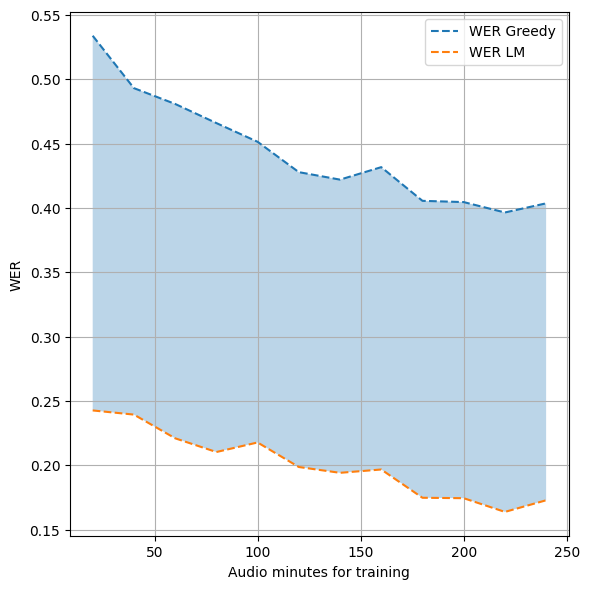

In [ ]:
import matplotlib.pyplot as plt

x = df_metrics_with_lm['audio_minutes'].to_numpy()
y1 = df_metrics_with_lm['wer_greedy'].to_numpy()
y2 = df_metrics_with_lm['wer_lm'].to_numpy()

plt.figure(figsize=(6,6))

# Líneas punteadas
plt.plot(x, y1, linestyle='--', label='WER Greedy')
plt.plot(x, y2, linestyle='--', label='WER LM')

# Área con opacidad
plt.fill_between(x, y1, y2, alpha=0.3)

plt.xlabel('Audio minutes for training')
plt.ylabel('WER')

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Cargamos el mejor modelo
## feature extractor + tokenizer + model + decoder_lm

In [16]:
from transformers import Wav2Vec2ForCTC, AutoProcessor, Wav2Vec2ProcessorWithLM
from pyctcdecode import build_ctcdecoder
import tempfile
from huggingface_hub import HfApi

api = HfApi()

# ----- configuración -----
SOURCE_REPO = f"{user}/mms-maya-240min"      # el mejor modelo
TARGET_REPO = f"{user}/mayan_best_model"     # repo destino
TARGET_LANG = "yua"
LM_PATH     = "/content/drive/MyDrive/thesis-mayan-ai/language_model/lm_3gram.arpa"

# ----- 1. modelo + processor del repo origen -----
processor = AutoProcessor.from_pretrained(SOURCE_REPO)
processor.tokenizer.set_target_lang(TARGET_LANG)
model = Wav2Vec2ForCTC.from_pretrained(SOURCE_REPO)

# ----- 2. unigramas (mismo archivo que ya usabas) -----
with open("./language_model/train_dataset_lm.txt") as f:
    unigrams = list({w for line in f for w in line.strip().split()})

# ----- 3. decoder con LM -----
vocab_dict  = processor.tokenizer.get_vocab()
labels      = [tok for tok, _ in sorted(vocab_dict.items(), key=lambda kv: kv[1])]

decoder_lm  = build_ctcdecoder(
    labels=labels,
    kenlm_model_path=LM_PATH,
    unigrams=unigrams,
    alpha=alpha,
    beta=beta,
)

# ----- 4. envolver processor + decoder -----
processor_with_lm = Wav2Vec2ProcessorWithLM(
    feature_extractor=processor.feature_extractor,
    tokenizer=processor.tokenizer,
    decoder=decoder_lm,
)

# ----- 5. subir todo al repo nuevo -----
model.push_to_hub(TARGET_REPO)

# El processor con LM se sube manualmente para esquivar el bug de
# max_shard_size en Wav2Vec2ProcessorWithLM.save_pretrained()
with tempfile.TemporaryDirectory() as tmp:
    processor_with_lm.save_pretrained(tmp)
    api.upload_folder(
        folder_path=tmp,
        repo_id=TARGET_REPO,
        repo_type="model",
        commit_message="Add processor with LM (KenLM 3-gram decoder)",
    )

print(f"Listo. Repo: https://huggingface.co/{TARGET_REPO}")

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pacbl13/model.safetensors:   4%|3         |  152MB / 3.86GB            

No files have been modified since last commit. Skipping to prevent empty commit.


Listo. Repo: https://huggingface.co/mau-cr/mayan_best_model
Listo. Repo: https://huggingface.co/mau-cr/mayan_best_model


## Probar modelo

In [17]:
from IPython.display import Javascript, display
from google.colab import output
from base64 import b64decode

RECORD_JS = """
const sleep = t => new Promise(r => setTimeout(r, t))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  const recorder = new MediaRecorder(stream)
  const chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async () => {
    const blob = new Blob(chunks)
    const text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
  stream.getTracks().forEach(t => t.stop())
})
"""

def grabar(segundos=5, salida="grabacion.wav"):
    print(f"Grabando {segundos} segundos... habla ahora.")
    display(Javascript(RECORD_JS))
    data = output.eval_js(f"record({segundos * 1000})")
    audio_bytes = b64decode(data.split(",")[1])

    with open("grabacion_raw.webm", "wb") as f:
        f.write(audio_bytes)

    # Convertir a wav mono 16 kHz, que es lo que espera el modelo
    !ffmpeg -y -loglevel error -i grabacion_raw.webm -ar 16000 -ac 1 {salida}
    print(f"Listo. Audio guardado en {salida}")
    return salida

Cargar modelo

In [23]:
import librosa
import torch
from transformers import AutoProcessor, AutoModelForCTC

REPO = f"{user}/mayan_best_model"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(REPO)
model = AutoModelForCTC.from_pretrained(REPO).to(device).eval()

print("Tipo de processor:", type(processor).__name__)   # debe ser Wav2Vec2ProcessorWithLM
print("Dispositivo:", device)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

Tipo de processor: Wav2Vec2ProcessorWithLM
Dispositivo: cuda


In [42]:
ruta_audio = grabar(segundos=6)   # ajusta los segundos que necesites
señal, sr = librosa.load(ruta_audio, sr=16000, mono=True)

Grabando 6 segundos... habla ahora.


<IPython.core.display.Javascript object>

Listo. Audio guardado en grabacion.wav


In [43]:
inputs = processor(señal, sampling_rate=16000, return_tensors="pt").to(device)

with torch.no_grad():
    logits = model(**inputs).logits

# Decodificación con LM — al ser Wav2Vec2ProcessorWithLM, batch_decode usa beam search + KenLM automáticamente
transcripcion_lm = processor.batch_decode(logits.cpu().numpy()).text[0]

# Decodificación greedy (sin LM) para comparar
pred_ids = torch.argmax(logits, dim=-1)
print("Transcripción :", transcripcion_lm)

Transcripción : bix a beele'ex


In [44]:
!pip install -q gradio

In [46]:
import gradio as gr
import librosa
import numpy as np
import torch
from transformers import AutoProcessor, AutoModelForCTC

# ----- 1. carga única al iniciar la app -----
REPO = f"{user}/mayan_best_model"
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Cargando modelo...")
processor = AutoProcessor.from_pretrained(REPO)
model = AutoModelForCTC.from_pretrained(REPO).to(device).eval()
print(f"Listo. Processor: {type(processor).__name__} | Dispositivo: {device}")


# ----- 2. función de inferencia -----
def transcribir(audio):
    """
    audio = (sample_rate, numpy_array) que es lo que entrega Gradio
    cuando type='numpy' en el componente Audio.
    """
    if audio is None:
        return "⚠️ No recibí audio. Graba algo o sube un archivo.", ""

    sr, señal = audio

    # Gradio puede entregar int16; lo pasamos a float32 normalizado
    if señal.dtype != np.float32:
        señal = señal.astype(np.float32) / np.iinfo(señal.dtype).max

    # Si viene estéreo, lo pasamos a mono
    if señal.ndim > 1:
        señal = señal.mean(axis=1)

    # Resampleo a 16 kHz si hace falta
    if sr != 16000:
        señal = librosa.resample(señal, orig_sr=sr, target_sr=16000)

    # Inferencia
    inputs = processor(señal, sampling_rate=16000, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits

    # Decodificación con LM
    transcripcion_lm = processor.batch_decode(logits.cpu().numpy()).text[0]

    # Decodificación greedy para comparar
    pred_ids = torch.argmax(logits, dim=-1)
    transcripcion_greedy = processor.tokenizer.batch_decode(pred_ids)[0]

    return transcripcion_lm, transcripcion_greedy


# ----- 3. interfaz -----
demo = gr.Interface(
    fn=transcribir,
    inputs=gr.Audio(
        sources=["microphone", "upload"],
        type="numpy",
        label="Audio en maya yucateco",
    ),
    outputs=[
        gr.Textbox(label="Transcripción (con modelo de lenguaje)"),
        gr.Textbox(label="Transcripción greedy (sin LM)"),
    ],
    title="ASR para Maya Yucateco",
    description=(
        "Modelo MMS-1b-all ajustado con 222 minutos de audio en maya yucateco "
        "y un decoder de beam search con KenLM (3-gramas). "
        "Graba desde el micrófono o sube un archivo de audio."
    ),
    examples=None,
    flagging_mode="never",
)

demo.launch(share=True, debug=True)

Cargando modelo...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

Listo. Processor: Wav2Vec2ProcessorWithLM | Dispositivo: cuda
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://606104f7d66a6e5dca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://606104f7d66a6e5dca.gradio.live
